# Firm size and labor productivity in Uzbekistan (WBES 2024)

Question: do bigger firms produce more sales per worker?

**Bottom line:** the data do not show that larger firms have higher sales per worker. In the main cleaned size-dummy specification, Large firms have significantly lower sales per worker than Small firms, while Medium firms are not statistically different from Small firms. The sales-employment elasticity is below 1 point-estimate-wise and is sensitive to the consistency thresholds. The negative size gap is smaller or becomes statistically insignificant in some robustness checks, so its strength depends on specification.

The main cleaned size-dummy result gives a Large coefficient of -0.456 (p = 0.033) relative to Small firms. Restricting the analysis to firms with observed labor costs gives -0.306 (p = 0.139). A separate ×1,000 sales-rescaling sensitivity check gives a Large coefficient of 0.151 (p = 0.464) and an elasticity of 1.041 (SE = 0.059; p = 0.489 for elasticity = 1). Because that rescaling is an ad-hoc assumption based on suspicious low-productivity observations, it is treated as a sensitivity check rather than a verified correction.


## Step 1: Load data and build variables (all in one place)

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

df = pd.read_stata("../data/raw/Uzbekistan-2024-full-data.dta")
print("Data shape:", df.shape)

def to_num(s):
    """Convert to numeric; 'Don't know' and other text become NaN."""
    return pd.to_numeric(s.astype(str), errors="coerce")

# Core variables
df["sales"] = to_num(df["d2"])
df["employees"] = to_num(df["l1"])
valid = (df["sales"] > 0) & (df["employees"] > 0)
df["productivity"] = np.where(valid, df["sales"] / df["employees"], np.nan)
df["log_productivity"] = np.log(df["productivity"])
df["log_employees"] = np.log(df["employees"].where(df["employees"] > 0))

# Size categories ('Below 5' merged into Small)
df["firm_size"] = pd.cut(df["employees"], bins=[0, 19, 99, np.inf],
                         labels=["Small", "Medium", "Large"])

# Firm age relative to survey year (a20y = 2023)
df["firm_age"] = df["a20y"] - to_num(df["b5"])

# Foreign ownership (b2b) and exporter (d3b + d3c); "don't know" stays NaN
df["foreign_owned"] = np.where(to_num(df["b2b"]) > 0, 1,
                               np.where(to_num(df["b2b"]) == 0, 0, np.nan))
df["export_share"] = to_num(df["d3b"]) + to_num(df["d3c"])
df["exporter"] = np.where(df["export_share"] > 0, 1,
                          np.where(df["export_share"] == 0, 0, np.nan))

# Variables used by the elasticity specification are defined here so every later cell can run from a fresh kernel.
df["log_sales"] = np.log(df["sales"].where(df["sales"] > 0))
rhs2 = ("log_employees + firm_age + foreign_owned + exporter"
        " + C(stratificationsectorcode) + C(stratificationregioncode)")
cols = ["log_sales", "log_employees", "firm_age", "foreign_owned", "exporter",
        "stratificationsectorcode", "stratificationregioncode"]

print(df["firm_size"].value_counts(dropna=False))
print(df[["productivity", "log_employees", "firm_age"]].describe())
print(df["foreign_owned"].value_counts(dropna=False))
print(df["exporter"].value_counts(dropna=False))
print("a20y values:", df["a20y"].value_counts(dropna=False).head())

Data shape: (1008, 340)
firm_size
Small     439
Medium    331
Large     212
NaN        26
Name: count, dtype: int64
       productivity  log_employees    firm_age
count  9.000000e+02     982.000000  991.000000
mean   5.596238e+10       3.363581   12.347124
std    8.329606e+11       1.402292   11.484491
min    4.000000e+03       0.000000    0.000000
25%    2.500000e+07       2.302585    5.000000
50%    8.582589e+07       3.135494   10.000000
75%    2.694906e+08       4.317488   16.000000
max    2.083333e+13       7.824046  121.000000
foreign_owned
0.0    944
1.0     47
NaN     17
Name: count, dtype: int64
exporter
0.0    896
1.0     98
NaN     14
Name: count, dtype: int64
a20y values: a20y
2023    1008
Name: count, dtype: int64


## Step 2: Inspect the extreme productivity values
Many top and bottom values are implausible (e.g. 2.5e14 UZS sales for 12 workers).

In [2]:
cols_out = ["sales", "employees", "productivity", "firm_size", "stratificationsectorcode"]
print("=== 12 HIGHEST productivity ===")
print(df[cols_out].sort_values("productivity", ascending=False).head(12).to_string())
print("\n=== 12 LOWEST productivity ===")
print(df[cols_out].sort_values("productivity").head(12).to_string())
print("\n=== Productivity percentiles ===")
print(df["productivity"].quantile([0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]))

=== 12 HIGHEST productivity ===
            sales  employees  productivity firm_size stratificationsectorcode
877  2.500000e+14       12.0  2.083333e+13     Small                 Textiles
527  5.600000e+13        5.0  1.120000e+13     Small                 Garments
215  5.000000e+13       10.0  5.000000e+12     Small                 Textiles
689  3.500000e+13        8.0  4.375000e+12     Small                 Textiles
374  7.672500e+13       21.0  3.653571e+12    Medium                 Textiles
260  4.840900e+13       18.0  2.689389e+12     Small                 Textiles
879  1.513060e+14      100.0  1.513060e+12     Large             Construction
722  3.700000e+11        2.0  1.850000e+11     Small      Other Manufacturing
825  1.521000e+13      110.0  1.382727e+11     Large           Other Services
71   1.670000e+13      140.0  1.192857e+11     Large      Other Manufacturing
581  3.200000e+12       36.0  8.888889e+10    Medium      Other Manufacturing
445  1.500000e+12       30.0  5.

## Step 3: Compare four ways of handling outliers
The Large-firm coefficient shrinks as extreme values are removed, so the raw result is fragile.

In [3]:
df["lp_raw"] = df["log_productivity"]

lo, hi = df["productivity"].quantile([0.01, 0.99])
df["lp_wins"] = np.log(df["productivity"].clip(lo, hi))

def trim_log(series, lo_q, hi_q):
    lo_v, hi_v = series.quantile(lo_q), series.quantile(hi_q)
    return series.where((series >= lo_v) & (series <= hi_v))

df["lp_trim1"] = trim_log(df["log_productivity"], 0.01, 0.99)
df["lp_trim5"] = trim_log(df["log_productivity"], 0.05, 0.95)

rhs = ('C(firm_size, Treatment(reference="Small"))'
       ' + firm_age + foreign_owned + exporter'
       ' + C(stratificationsectorcode) + C(stratificationregioncode)')
k_med = 'C(firm_size, Treatment(reference="Small"))[T.Medium]'
k_large = 'C(firm_size, Treatment(reference="Small"))[T.Large]'

rows = []
for name in ["lp_raw", "lp_wins", "lp_trim1", "lp_trim5"]:
    d = df[[name, "firm_size", "firm_age", "foreign_owned", "exporter",
            "stratificationsectorcode", "stratificationregioncode"]].dropna()
    m = smf.ols(f"{name} ~ {rhs}", data=d).fit(cov_type="HC1")
    rows.append({"outcome": name, "n": int(m.nobs),
                 "medium_coef": round(m.params[k_med], 3),
                 "medium_p": round(m.pvalues[k_med], 3),
                 "large_coef": round(m.params[k_large], 3),
                 "large_p": round(m.pvalues[k_large], 3)})
pd.DataFrame(rows)

,outcome,n,medium_coef,medium_p,large_coef,large_p
0,lp_raw,887,-0.140,0.435,-0.876,0.001
1,lp_wins,887,-0.083,0.616,-0.811,0.001
2,lp_trim1,870,0.053,0.726,-0.629,0.006
3,lp_trim5,798,0.032,0.793,0.008,0.963


## Step 4: Where are the tails? Plus a median regression
Large firms are heavily over-represented in the bottom 5% of productivity.

In [4]:
lo5, hi5 = df["log_productivity"].quantile([0.05, 0.95])
df["tail"] = np.where(df["log_productivity"] < lo5, "bottom 5%",
             np.where(df["log_productivity"] > hi5, "top 5%", "middle 90%"))
d = df[df["log_productivity"].notna() & df["firm_size"].notna()]
print("Counts:")
print(pd.crosstab(d["firm_size"], d["tail"]))
print("\nShares within each size group:")
print(pd.crosstab(d["firm_size"], d["tail"], normalize="index").round(3))

d2 = df[["log_productivity", "firm_size", "firm_age", "foreign_owned", "exporter",
         "stratificationsectorcode", "stratificationregioncode"]].dropna()
q = smf.quantreg(f"log_productivity ~ {rhs}", d2).fit(q=0.5)
print("\nMedian regression, n =", int(q.nobs))
print(q.params[[k_med, k_large]].round(3))
print(q.pvalues[[k_med, k_large]].round(3))

Counts:
tail       bottom 5%  middle 90%  top 5%
firm_size                               
Small             10         379      23
Medium            10         282      17
Large             25         149       5

Shares within each size group:
tail       bottom 5%  middle 90%  top 5%
firm_size                               
Small          0.024       0.920   0.056
Medium         0.032       0.913   0.055
Large          0.140       0.832   0.028

Median regression, n = 887
C(firm_size, Treatment(reference="Small"))[T.Medium]    0.223
C(firm_size, Treatment(reference="Small"))[T.Large]    -0.335
dtype: float64
C(firm_size, Treatment(reference="Small"))[T.Medium]    0.147
C(firm_size, Treatment(reference="Small"))[T.Large]     0.086
dtype: float64


## Step 5: Inspect the suspicious large firms (bottom 5% of productivity)

In [5]:
low_large = df[(df["firm_size"] == "Large") & (df["log_productivity"] < lo5)]
print("Number of firms:", len(low_large))
print(low_large[["sales", "employees", "productivity", "stratificationsectorcode"]]
      .sort_values("productivity").to_string())
print("\nColumns starting with 'n':")
print([c for c in df.columns if c.startswith("n")])

Number of firms: 25
           sales  employees   productivity stratificationsectorcode
469   28808000.0      479.0   60141.962422           Other Services
884   47000000.0      420.0  111904.761905                 Garments
534   60415139.0      381.0  158569.918635                 Textiles
578   36246000.0      214.0  169373.831776                   Retail
705   23872444.0      122.0  195675.770492           Other Services
996  320000000.0     1550.0  206451.612903           Other Services
912  550000000.0     2500.0  220000.000000                 Textiles
740   50077000.0      220.0  227622.727273                 Garments
756   26190195.0      113.0  231771.637168      Other Manufacturing
990   50000000.0      200.0  250000.000000                 Garments
862   40474802.0      145.0  279136.565517                   Retail
158  225703000.0      747.0  302145.917001             Construction
574  696482000.0     2046.0  340411.534702      Other Manufacturing
670  110000000.0      321.0 

In [6]:
# Sensitivity check: rescale sales for suspicious large firms
# This is an ad-hoc test of a possible unit mismatch.

df["sales_rescaled"] = df["sales"].copy()

df.loc[low_large.index, "sales_rescaled"] = (
    df.loc[low_large.index, "sales"] * 1000
)

df["log_sales_rescaled"] = np.log(
    df["sales_rescaled"].where(df["sales_rescaled"] > 0)
)

d_rescaled = df[
    ["log_sales_rescaled", "log_employees", "firm_age",
     "foreign_owned", "exporter",
     "stratificationsectorcode", "stratificationregioncode"]
].dropna()

m_rescaled = smf.ols(
    f"log_sales_rescaled ~ {rhs2}",
    data=d_rescaled
).fit(cov_type="HC1")

print("Rescaled-sales sensitivity check")
print("n =", int(m_rescaled.nobs))

print("\nElasticity:")
print(round(m_rescaled.params["log_employees"], 3))

print("\nSE:")
print(round(m_rescaled.bse["log_employees"], 3))

print("\nP-value vs elasticity = 1:")
t_rescaled = m_rescaled.t_test("log_employees = 1")
print(round(float(t_rescaled.pvalue), 4))

Rescaled-sales sensitivity check
n = 887

Elasticity:
1.041

SE:
0.059

P-value vs elasticity = 1:
0.4892


## Step 6: Cross-check against labor costs (n2a) and test the units hypothesis

In [7]:
path = "../data/raw/Uzbekistan-2024-full-data.dta"
with pd.read_stata(path, iterator=True) as r:
    labels = r.variable_labels()
for c in ["d2", "n2a", "n2b", "n2e", "n2i", "n2k", "n2l", "n3", "n5a", "n5b", "n7a", "n11"]:
    print(c, "-", labels.get(c))

df["labor_cost"] = to_num(df["n2a"])
df["labor_cost_per_emp"] = df["labor_cost"] / df["employees"]
group = np.where(df.index.isin(low_large.index), "suspicious large", "all others")
print("\nLabor cost per employee (n2a / employees):")
print(df.groupby(group)["labor_cost_per_emp"].agg(["count", "median"]))

print("\nMedian labor share among suspicious large firms after rescaling sales:")
for multiplier in [1, 10, 100, 1000, 10000, 1_000_000]:
    scaled_share = df.loc[low_large.index, "labor_cost"] / (df.loc[low_large.index, "sales"] * multiplier)
    print(f"sales x{multiplier:,}: {scaled_share.median():.6f}")


d2 - In Last Fiscal Year, What Were This EstablishmentâS Total Annual Sales?
n2a - Total Labor Cost (Incl. Wages, Salaries, Bonuses, Etc) In Last Fiscal Year
n2b - Total Annual Costs of Electricity In Last Fiscal Year
n2e - Cost of Raw Materials And Intermediate Goods Used In Prod. In Last Fiscal Year
n2i - Total Annual Cost of Finished Goods/Materials Bought To Resell In Last FY
n2k - Total Annual Cost of Water
n2l - Total Annual Cost of high-speed, fixed broadband internet
n3 - What were the establishment's sales 3 years ago?
n5a - Total Annual Expenditure For Purchases of Equipment In Last FY
n5b - Total Annual Expenditure For Purchases of Land And Buildings In Last FY
n7a - Cost For Establishment To Re-Purchase All of Its Machinery
n11 - Effective income-based tax rate

Labor cost per employee (n2a / employees):
                  count        median
all others          826  1.800000e+07
suspicious large     19  1.818182e+07

Median labor share among suspicious large firms after r

## Step 7: Flag firms whose sales contradict their labor costs, then re-estimate
Flag if labor cost > sales (`HIGH`) or labor cost < 0.1% of sales (`LOW`). Change the thresholds to test robustness.

In [8]:
df["labor_share"] = np.where(df["sales"] > 0, df["labor_cost"] / df["sales"], np.nan)
print(df["labor_share"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

HIGH, LOW = 1.0, 0.001
df["flag_high"] = df["labor_share"] > HIGH
df["flag_low"] = df["labor_share"] < LOW
df["flagged_main"] = df["flag_high"] | df["flag_low"]

print("\nFlagged firms by size:")
print(pd.crosstab(df["firm_size"], [df["flag_high"], df["flag_low"]]))
print("\nOf the suspicious large firms, flagged:", df.loc[low_large.index, "flag_high"].sum())

df["lp_clean"] = df["log_productivity"].where(~(df["flag_high"] | df["flag_low"]))
d = df[["lp_clean", "firm_size", "firm_age", "foreign_owned", "exporter",
        "stratificationsectorcode", "stratificationregioncode"]].dropna()
m = smf.ols(f"lp_clean ~ {rhs}", data=d).fit(cov_type="HC1")
print("\nn =", int(m.nobs))
print(m.params[[k_med, k_large]].round(3))
print(m.pvalues[[k_med, k_large]].round(3))

0.01    1.200000e-04
0.05    8.863955e-03
0.25    7.125642e-02
0.50    2.109405e-01
0.75    5.760000e-01
0.95    6.828978e+02
0.99    1.296176e+06
Name: labor_share, dtype: float64

Flagged firms by size:
flag_high False       True 
flag_low  False True  False
firm_size                  
Small       379     5    55
Medium      289     2    40
Large       179     8    25

Of the suspicious large firms, flagged: 15

n = 752
C(firm_size, Treatment(reference="Small"))[T.Medium]    0.153
C(firm_size, Treatment(reference="Small"))[T.Large]    -0.456
dtype: float64
C(firm_size, Treatment(reference="Small"))[T.Medium]    0.315
C(firm_size, Treatment(reference="Small"))[T.Large]     0.033
dtype: float64


In [9]:
# Sensitivity check: size-group differences after rescaling suspicious large firms

df["productivity_rescaled"] = (
    df["sales_rescaled"] / df["employees"]
)

df["lp_rescaled"] = np.log(
    df["productivity_rescaled"].where(df["productivity_rescaled"] > 0)
)

d_rescaled_size = df[
    ["lp_rescaled", "firm_size", "firm_age", "foreign_owned", "exporter",
     "stratificationsectorcode", "stratificationregioncode"]
].dropna()

m_rescaled_size = smf.ols(
    f"lp_rescaled ~ {rhs}",
    data=d_rescaled_size
).fit(cov_type="HC1")

print("Rescaled-sales size-group sensitivity check")
print("\nn =", int(m_rescaled_size.nobs))

print("\nCoefficients:")
print(m_rescaled_size.params[[k_med, k_large]].round(3))

print("\nP-values:")
print(m_rescaled_size.pvalues[[k_med, k_large]].round(3))


Rescaled-sales size-group sensitivity check

n = 887

Coefficients:
C(firm_size, Treatment(reference="Small"))[T.Medium]   -0.101
C(firm_size, Treatment(reference="Small"))[T.Large]     0.151
dtype: float64

P-values:
C(firm_size, Treatment(reference="Small"))[T.Medium]    0.573
C(firm_size, Treatment(reference="Small"))[T.Large]     0.464
dtype: float64


## Step 7b: Does cleaning disproportionately remove low-productivity firms?

Because labor cost > sales is mechanically associated with low measured sales per worker, the cleaning rule can remove observations that contribute to a negative size-productivity relationship. This diagnostic compares flagged and retained firms by size and reports their productivity distribution.

In [10]:
df["flagged_main"] = df["flag_high"] | df["flag_low"]

# Composition by employee-based size category
composition = pd.crosstab(df["firm_size"], df["flagged_main"])
composition.columns = ["retained" if x is False else "flagged" for x in composition.columns]
composition["flagged_share"] = composition["flagged"] / composition[["retained", "flagged"]].sum(axis=1)
print("Flagged observations by size:")
print(composition.round(3).to_string())

# Productivity distribution among retained vs flagged observations
diag = df.loc[df["log_productivity"].notna() & df["firm_size"].notna(), ["firm_size", "flagged_main", "productivity", "labor_share"]].copy()
diag["status"] = np.where(diag["flagged_main"], "flagged", "retained")
summary = (diag.groupby(["firm_size", "status"])["productivity"]
           .agg(n="count", median="median", p10=lambda x: x.quantile(.10), p90=lambda x: x.quantile(.90))
           .reset_index())
print("\nProductivity distribution by size and cleaning status:")
print(summary.round({"median":2, "p10":2, "p90":2}).to_string(index=False))

# Compare the large-firm coefficient before and after cleaning
d_all = df[["log_productivity", "firm_size", "firm_age", "foreign_owned", "exporter", "stratificationsectorcode", "stratificationregioncode"]].dropna()
d_clean = df.loc[~df["flagged_main"], ["log_productivity", "firm_size", "firm_age", "foreign_owned", "exporter", "stratificationsectorcode", "stratificationregioncode"]].dropna()
m_all = smf.ols(f"log_productivity ~ {rhs}", data=d_all).fit(cov_type="HC1")
m_clean = smf.ols(f"log_productivity ~ {rhs}", data=d_clean).fit(cov_type="HC1")
print("\nLarge coefficient before cleaning:", round(m_all.params[k_large], 3))
print("Large coefficient after cleaning:", round(m_clean.params[k_large], 3))


Flagged observations by size:
           retained  flagged  flagged_share
firm_size                                  
Small           379       60          0.137
Medium          289       42          0.127
Large           179       33          0.156

Productivity distribution by size and cleaning status:
firm_size   status   n       median         p10          p90
    Small  flagged  60  26910250.00  2599371.43 3.671088e+09
    Small retained 352  95500000.00 12920833.33 7.369464e+08
   Medium  flagged  42  12500000.00   813557.04 9.682960e+09
   Medium retained 267 116666666.67 14261000.00 5.718581e+08
    Large  flagged  33   4621072.09   221524.55 1.460864e+09
    Large retained 146  83183384.89  4722186.51 5.837250e+08

Large coefficient before cleaning: -0.876
Large coefficient after cleaning: -0.456


## Step 7c: Audit of extreme high-sales observations

The low-sales tail was checked against labor costs. We perform the symmetric check for unusually high sales so that the analysis does not assume that an extreme sales value is erroneous without examining independent information.

In [11]:
# Audit the upper tail of sales per employee
upper_audit = (df.loc[df["productivity"].notna(), ["productivity", "sales", "employees", "labor_cost", "labor_share", "firm_size", "flagged_main"]]
              .sort_values("productivity", ascending=False)
              .head(20)
              .copy())
print(upper_audit.to_string(index=False))

print("\nMedian labor-cost share among the 20 highest-sales-per-employee firms:",
      round(upper_audit["labor_share"].median(), 6))
print("Flagged among the 20 highest-sales-per-employee firms:",
      int(upper_audit["flagged_main"].sum()), "of", len(upper_audit))


 productivity        sales  employees   labor_cost  labor_share firm_size  flagged_main
 2.083333e+13 2.500000e+14       12.0 4.506530e+14     1.802612     Small          True
 1.120000e+13 5.600000e+13        5.0 9.000000e+13     1.607143     Small          True
 5.000000e+12 5.000000e+13       10.0 7.147900e+13     1.429580     Small          True
 4.375000e+12 3.500000e+13        8.0 7.200000e+13     2.057143     Small          True
 3.653571e+12 7.672500e+13       21.0 3.030535e+14     3.949867    Medium          True
 2.689389e+12 4.840900e+13       18.0 6.575670e+14    13.583569     Small          True
 1.513060e+12 1.513060e+14      100.0          NaN          NaN     Large         False
 1.850000e+11 3.700000e+11        2.0 4.600000e+10     0.124324     Small         False
 1.382727e+11 1.521000e+13      110.0 1.715600e+13     1.127942     Large          True
 1.192857e+11 1.670000e+13      140.0 6.000000e+08     0.000036     Large          True
 8.888889e+10 3.200000e+12      

## Step 7d: Inspect the labor-share distribution

The labor-share distribution is highly right-skewed. A log-scale histogram provides a visual diagnostic of the extreme upper tail before interpreting alternative consistency thresholds.


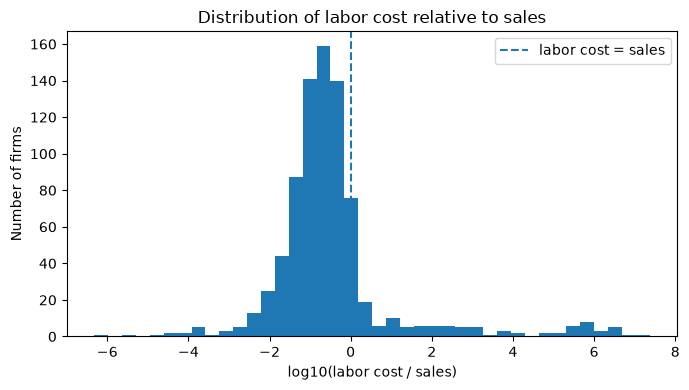

In [12]:
import matplotlib.pyplot as plt
plot_share = df.loc[df["labor_share"] > 0, "labor_share"]
plt.figure(figsize=(7, 4))
plt.hist(np.log10(plot_share), bins=40)
plt.axvline(0, linestyle="--", label="labor cost = sales")
plt.xlabel("log10(labor cost / sales)")
plt.ylabel("Number of firms")
plt.title("Distribution of labor cost relative to sales")
plt.legend()
plt.tight_layout()
plt.show()


## Step 7e: Exclude firms with unverifiable labor costs

Firms with missing `n2a` cannot be checked by the labor-cost consistency rule. This robustness check excludes those observations from the cleaned sample and re-estimates both main specifications.


In [13]:
df["labor_cost_observed"] = df["labor_cost"].notna()
verified_clean = (~df["flagged_main"]) & df["labor_cost_observed"]
d_verified = df.loc[verified_clean, ["log_productivity", "firm_size", "firm_age", "foreign_owned", "exporter", "stratificationsectorcode", "stratificationregioncode"]].dropna()
m_verified = smf.ols(f"log_productivity ~ {rhs}", data=d_verified).fit(cov_type="HC1")
d_verified_elast = df.loc[verified_clean, cols].dropna()
m_verified_elast = smf.ols(f"log_sales ~ {rhs2}", data=d_verified_elast).fit(cov_type="HC1")
t_verified = m_verified_elast.t_test("log_employees = 1")
print("Verified labor-cost sample size:", int(m_verified.nobs))
print("Large coefficient:", round(m_verified.params[k_large], 3))
print("Large p-value:", round(m_verified.pvalues[k_large], 3))
print("Elasticity:", round(m_verified_elast.params["log_employees"], 3))
print("Elasticity SE:", round(m_verified_elast.bse["log_employees"], 3))
print("Elasticity p vs 1:", round(float(t_verified.pvalue), 4))


Verified labor-cost sample size: 663
Large coefficient: -0.306
Large p-value: 0.139
Elasticity: 0.939
Elasticity SE: 0.065
Elasticity p vs 1: 0.346


## Step 8: Elasticity of sales with respect to employment
Avoids putting employment in the denominator of the outcome. Elasticity = 1 corresponds to proportional scaling of sales with employment; values below 1 imply that sales per worker decline with employment.

In [14]:


rows = []
for label, mask in [("all valid firms", pd.Series(True, index=df.index)),
                    ("consistency-cleaned", ~df["flagged_main"])]:
    d = df.loc[mask, cols].dropna()
    m = smf.ols(f"log_sales ~ {rhs2}", data=d).fit(cov_type="HC1")
    t = m.t_test("log_employees = 1")
    rows.append({"sample": label, "n": int(m.nobs),
                 "elasticity": round(m.params["log_employees"], 3),
                 "se": round(m.bse["log_employees"], 3),
                 "p_vs_1": round(float(t.pvalue), 4)})
pd.DataFrame(rows)

,sample,n,elasticity,se,p_vs_1
0,all valid firms,887,0.748,0.074,0.0006
1,consistency-cleaned,752,0.896,0.068,0.1283


## Step 9: Survey-weighted elasticity (`wmedian`)

In [15]:
d = df.loc[~df["flagged_main"], cols + ["wmedian"]].dropna()
mw = smf.wls(f"log_sales ~ {rhs2}", data=d, weights=d["wmedian"]).fit(cov_type="HC1")
t = mw.t_test("log_employees = 1")
print("n =", int(mw.nobs))
print("weighted elasticity:", round(mw.params["log_employees"], 3))
print("se:", round(mw.bse["log_employees"], 3))
print("p vs 1:", round(float(t.pvalue), 4))

n = 752
weighted elasticity: 0.851
se: 0.129
p vs 1: 0.2497


## Step 9b: Employee-based size categories versus survey size variable (`a6a`)

The regressions define firm size directly from reported permanent employees. The survey also contains `a6a`, a separate size-related variable. We compare the two rather than assuming they are identical.

In [16]:
size_strata = df[["firm_size", "a6a"]].dropna().copy()
print("Counts: employee-based firm size x survey a6a")
print(pd.crosstab(size_strata["firm_size"], size_strata["a6a"]).to_string())

print("\nShares within employee-based size category:")
print(pd.crosstab(size_strata["firm_size"], size_strata["a6a"], normalize="index").round(3).to_string())

print("\nSurvey a6a values:")
print(sorted(size_strata["a6a"].unique().tolist()))


Counts: employee-based firm size x survey a6a
a6a        Small  Medium  Large
firm_size                      
Small        301      99     39
Medium        83     183     65
Large         12      15    185

Shares within employee-based size category:
a6a        Small  Medium  Large
firm_size                      
Small      0.686   0.226  0.089
Medium     0.251   0.553  0.196
Large      0.057   0.071  0.873

Survey a6a values:
['Large', 'Medium', 'Small']


## Step 9c: Survey-weighted size-dummy regression

This estimates the same employee-based Small/Medium/Large productivity specification as the cleaned OLS model, but applies the survey's `wmedian` weights.

In [17]:
d_wdummy = df.loc[~df["flagged_main"], ["log_productivity", "firm_size", "firm_age", "foreign_owned", "exporter", "stratificationsectorcode", "stratificationregioncode", "wmedian"]].dropna()
m_wdummy = smf.wls(f"log_productivity ~ {rhs}", data=d_wdummy, weights=d_wdummy["wmedian"]).fit(cov_type="HC1")

print("n =", int(m_wdummy.nobs))
print("Weighted Medium coefficient:", round(m_wdummy.params[k_med], 3))
print("Weighted Medium p-value:", round(m_wdummy.pvalues[k_med], 3))
print("Weighted Large coefficient:", round(m_wdummy.params[k_large], 3))
print("Weighted Large p-value:", round(m_wdummy.pvalues[k_large], 3))

print("\nWeighted size-dummy regression coefficients:")
print(m_wdummy.params[[k_med, k_large]].round(3).to_string())


n = 752
Weighted Medium coefficient: -0.042
Weighted Medium p-value: 0.852
Weighted Large coefficient: -1.036
Weighted Large p-value: 0.004

Weighted size-dummy regression coefficients:
C(firm_size, Treatment(reference="Small"))[T.Medium]   -0.042
C(firm_size, Treatment(reference="Small"))[T.Large]    -1.036


## Step 10: Sensitivity to the labor-cost consistency thresholds

The main thresholds (labor cost > 100% of sales or < 0.1% of sales) are judgment calls. The table below re-estimates both the size-dummy and elasticity specifications while varying one threshold at a time. The upper-threshold labels refer to ratios of labor cost to sales: for example, `upper_0.5` means 50% of sales, while `upper_100` means 10,000% of sales.

Four of the seven alternative threshold rules reject an elasticity of 1 at the 5% level: `upper_0.5`, `upper_5`, `upper_10`, and `upper_100`. The other three do not: `upper_2` (p = 0.066), `lower_0.0005` (p = 0.133), and `lower_0.002` (p = 0.079). `upper_2` and `lower_0.002` are relatively close to the 5% cutoff. In contrast, the Large size coefficient remains negative and statistically significant at the 5% level under every threshold rule shown. Thus, this sensitivity analysis shows greater sensitivity in inference about proportional scaling than in the sign and significance of the Large size coefficient.

In [18]:
threshold_specs = [
    ("main", 1.0, 0.001),
    ("upper_0.5", 0.5, 0.001),
    ("upper_2", 2.0, 0.001),
    ("upper_5", 5.0, 0.001),
    ("upper_10", 10.0, 0.001),
    ("upper_100", 100.0, 0.001),
    ("lower_0.0005", 1.0, 0.0005),
    ("lower_0.002", 1.0, 0.002),
]

sensitivity_rows = []
for label, high_cut, low_cut in threshold_specs:
    flagged_s = (df["labor_share"] > high_cut) | (df["labor_share"] < low_cut)
    d_dummy = df.loc[~flagged_s, ["log_productivity", "firm_size", "firm_age", "foreign_owned", "exporter",
                                  "stratificationsectorcode", "stratificationregioncode"]].dropna()
    d_elast = df.loc[~flagged_s, cols].dropna()

    m_dummy = smf.ols(f"log_productivity ~ {rhs}", data=d_dummy).fit(cov_type="HC1")
    m_elast = smf.ols(f"log_sales ~ {rhs2}", data=d_elast).fit(cov_type="HC1")
    t_elast = m_elast.t_test("log_employees = 1")

    sensitivity_rows.append({
        "rule": label,
        "upper": high_cut,
        "lower": low_cut,
        "n_dummy": int(m_dummy.nobs),
        "medium_coef": m_dummy.params[k_med],
        "medium_p": m_dummy.pvalues[k_med],
        "large_coef": m_dummy.params[k_large],
        "large_p": m_dummy.pvalues[k_large],
        "n_elasticity": int(m_elast.nobs),
        "elasticity": m_elast.params["log_employees"],
        "elasticity_se": m_elast.bse["log_employees"],
        "elasticity_p_vs_1": float(t_elast.pvalue),
    })

sensitivity = pd.DataFrame(sensitivity_rows)
print(sensitivity.round({"medium_coef":3, "medium_p":3, "large_coef":3, "large_p":3, "elasticity":3, "elasticity_se":3, "elasticity_p_vs_1":3}).to_string(index=False))

        rule  upper  lower  n_dummy  medium_coef  medium_p  large_coef  large_p  n_elasticity  elasticity  elasticity_se  elasticity_p_vs_1
        main    1.0 0.0010      752        0.153     0.315      -0.456    0.033           752       0.896          0.068              0.128
   upper_0.5    0.5 0.0010      653        0.083     0.607      -0.595    0.008           653       0.848          0.072              0.034
     upper_2    2.0 0.0010      780        0.011     0.951      -0.520    0.028           780       0.864          0.074              0.066
     upper_5    5.0 0.0010      794       -0.048     0.787      -0.560    0.019           794       0.838          0.075              0.030
    upper_10   10.0 0.0010      800       -0.028     0.876      -0.531    0.026           800       0.850          0.075              0.044
   upper_100  100.0 0.0010      821       -0.193     0.297      -0.857    0.001           821       0.760          0.075              0.001
lower_0.0005    1.0 

## Additional data-quality limitation

The labor-cost consistency screen can miss joint unit errors if both sales and labor costs are mis-scaled in a way that leaves their ratio plausible. The screen is therefore a diagnostic for internal consistency, not proof that a particular reported variable is incorrect. The main cleaned sample also includes some firms with missing labor costs, which are not verifiable by this screen; the separate observed-labor-cost robustness check addresses this issue.

## Conclusion

The data do not support the claim that larger firms have higher sales per worker. In the main cleaned sample, the coefficient for Large firms is -0.456 (p = 0.033) relative to Small firms, while Medium firms are not statistically different from Small firms. The negative Large-firm gap is smaller or becomes statistically insignificant in some robustness checks, so its strength depends on specification.

The sales-employment elasticity is 0.896 (SE = 0.068) in the main cleaned sample and is not statistically different from 1 (p = 0.128). However, four of seven alternative consistency rules reject an elasticity of 1 at the 5% level: `upper_0.5`, `upper_5`, `upper_10`, and `upper_100`. `upper_2` and `lower_0.002` are relatively close to the 5% cutoff. Thus, inference about proportional scaling is sensitive to the consistency thresholds.

Restricting the analysis to firms with observed labor costs reduces the Large coefficient to -0.306 (p = 0.139). A separate sensitivity check that rescales sales for suspicious large firms by 1,000 gives a Large coefficient of 0.151 (p = 0.464) and an elasticity of 1.041 (SE = 0.059). Because this rescaling is an ad-hoc, outcome-selected assumption, it should not be treated as a verified correction.

Survey weighting also changes the size-dummy estimates: the weighted Large coefficient is -1.036 (p = 0.004), compared with -0.456 (p = 0.033) in the unweighted main cleaned sample. These weighted regressions are robustness checks rather than full survey-design estimates.

Overall, the analysis does not support higher sales per worker among larger firms. The results should be interpreted as associations, with particular attention to data consistency, threshold choices, missing labor-cost observations, weighting, and extreme observations.
